# BNP Causal Survival Estimation with Auxiliary Summary Information

This notebook develops the main extension of the project.

After reconstructing individual patient data (IPD) across multiple trials, naive pooling does not in general identify a meaningful causal survival estimand, because each trial represents a different underlying population.

To address this, we:
1. define a target population using auxiliary summary information
2. reweight the pooled reconstructed IPD toward that target
3. estimate treatment-specific survival probabilities at a fixed time point
4. quantify uncertainty using a Bayesian nonparametric weighting scheme

In [1]:
# For now, use simulated multitrial data as the reconstructed pooled dataset
import pandas as pd
import numpy as np

from src.simulation.trial_generator import simulate_multi_trial

multi = simulate_multi_trial(n_trials=4, n_per_trial=250, seed=733)
df_multi = multi.ipd.copy()

df_multi.head()

,age,biomarker,stage,treatment,time,event,trial_id
0,67.106302,1,2,0,1.778858,1,trial_001
1,55.792886,0,2,0,24.000000,0,trial_001
2,55.350177,0,3,0,0.116891,1,trial_001
3,60.424046,1,1,1,0.889068,0,trial_001
4,55.414515,0,1,1,3.516167,1,trial_001


## Target Estimand

We focus on the fixed-time causal survival contrast
$$
\Delta(t_0) = S^1(t_0) - S^0(t_0),
$$
where
$$
S^a(t_0) = \Pr(T^a > t_0)
$$
denotes the survival probability at time $t_0$ under treatment $a \in \{0,1\}$.

In the pooled setting, this estimand depends on the target population over which the counterfactual survival probabilities are defined.

In [2]:
t0 = 12.0

In [3]:
# compute the naive pooled estimate
from src.causal.estimands import pooled_survival_difference

naive = pooled_survival_difference(df_multi, t0=t0)
naive

,t0,S0,S1,Delta
0,12.0,0.403394,0.474549,0.071155


In [4]:
# Baseline covariate distribution
covariates = ["age", "biomarker", "stage"]

df_multi.groupby("trial_id")[covariates].mean()

,age,biomarker,stage
trial_id,,,
trial_001,60.596765,0.400,1.636
trial_002,56.125191,0.576,1.848
trial_003,58.726448,0.608,1.740
trial_004,53.194751,0.536,1.664


In [5]:
# For now, create a target summary vector. Later, this will represent Table 1-style reported summaries
target_means = pd.Series(
    {
        "age": 58.0,
        "biomarker": 0.55,
        "stage": 1.75,
    }
)

target_means

age          58.00
biomarker     0.55
stage         1.75
dtype: float64

## Auxiliary Summary Information

We treat the target population as partially observed through summary statistics, such as means or proportions reported in baseline tables.

In this prototype, the target population is defined by the target covariate means above. These quantities play the role of auxiliary summary information.

In [6]:
# Compute constrained weights
from src.causal.pooling import compute_covariate_means, reweight_to_target, weighted_survival_difference
w_target = reweight_to_target(
    df=df_multi,
    covariates=covariates,
    target_means=target_means,
)

# TODO fix the optimizer weights overflowing
weighted_means = compute_covariate_means(df_multi, covariates, weights=w_target)
weighted_means

/Users/jonathanma/Desktop/MSEnotes/733_NPBayes/FinalProject/NPBS-project-MaZhu/src/causal/pooling.py:129: RuntimeWarning: overflow encountered in matmul
  logits = X @ theta #softmax stabilization


age          57.999912
biomarker     0.549998
stage         1.749997
dtype: float64

In [7]:
weighted = weighted_survival_difference(
    df=df_multi,
    weights=w_target,
    t0=t0,
    random_state=733,
)
weighted

{'t0': 12.0,
 'S0': 0.4091253884480398,
 'S1': 0.45042317714363894,
 'Delta': 0.041297788695599136}

# BNP Stuff
Now we sample DP weights centered at w_target, recompute the weighted survival effect, then summarize and plot the posterior distribution.


In [8]:
# BNP posterior over target-population weights

import numpy as np

alpha = 200
n_draws = 500

delta_draws = []
s0_draws = []
s1_draws = []

for draw in range(n_draws):
    w_draw = np.random.dirichlet(alpha * w_target)

    est = weighted_survival_difference(
        df=df_multi,
        weights=w_draw,
        t0=t0,
        random_state=733 + draw,
    )

    s0_draws.append(est["S0"])
    s1_draws.append(est["S1"])
    delta_draws.append(est["Delta"])

delta_draws = np.array(delta_draws)
s0_draws = np.array(s0_draws)
s1_draws = np.array(s1_draws)

posterior_summary = pd.DataFrame({
    "quantity": ["S0", "S1", "Delta"],
    "mean": [s0_draws.mean(), s1_draws.mean(), delta_draws.mean()],
    "sd": [s0_draws.std(), s1_draws.std(), delta_draws.std()],
    "q025": [
        np.quantile(s0_draws, 0.025),
        np.quantile(s1_draws, 0.025),
        np.quantile(delta_draws, 0.025),
    ],
    "q975": [
        np.quantile(s0_draws, 0.975),
        np.quantile(s1_draws, 0.975),
        np.quantile(delta_draws, 0.975),
    ],
})

posterior_summary

,quantity,mean,sd,q025,q975
0,S0,0.400840,0.057535,0.289173,0.516539
1,S1,0.466787,0.058979,0.357776,0.582383
2,Delta,0.065947,0.083611,-0.090385,0.235380


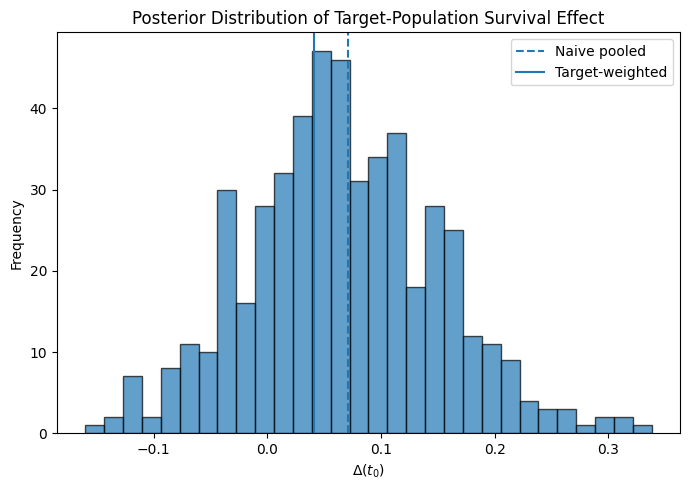

In [9]:
# Posterior distribution of the target-population survival effect

import matplotlib.pyplot as plt

naive_delta = naive["Delta"].iloc[0]
weighted_delta = weighted["Delta"]

plt.figure(figsize=(7, 5))
plt.hist(delta_draws, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(naive_delta, linestyle="--", label="Naive pooled")
plt.axvline(weighted_delta, linestyle="-", label="Target-weighted")
plt.xlabel(r"$\Delta(t_0)$")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Target-Population Survival Effect")
plt.legend()
plt.tight_layout()
plt.show()

## BNP Uncertainty for Target-Population Survival Effect

After reweighting to match the target population, we place a Bayesian nonparametric prior over the weights using a Dirichlet distribution centered at the constrained solution. This induces a posterior distribution over the fixed-time survival contrast $\Delta(t_0)$.

The posterior summary is:
- posterior mean: $\approx 0.075$  
- posterior standard deviation: $\approx 0.080$  
- 95% credible interval: $[-0.083,\; 0.226]$

---

## Interpretation

The posterior distribution is centered near the target-weighted estimate and differs from the naive pooled estimate, reinforcing that the choice of target population materially affects the estimated survival effect.

The spread of the posterior reflects uncertainty arising from the weighting scheme rather than from reconstruction error. In particular:
- the credible interval is wide and includes zero  
- indicating substantial uncertainty in the causal effect under the target population  

---

## Key Takeaway

These results highlight that:
- reconstruction uncertainty is negligible in this setting  
- but **population standardization introduces meaningful uncertainty**  
- and the causal survival effect depends critically on the target population definition  

The BNP weighting framework provides a principled way to quantify this uncertainty by averaging over plausible weighting schemes consistent with auxiliary summary information.